<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_8_deep_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 8: Implementation of deep feed forward ANN with 4 hidden layer backpropagation

This notebook demonstrates how to build and train a "deep" feedforward Artificial Neural Network (ANN) by stacking exactly 4 hidden layers. We will use the Fashion MNIST dataset to classify articles of clothing.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Data Loading and Preprocessing
We load the Fashion MNIST dataset, which contains 70,000 grayscale images in 10 categories, and normalize the pixel values.

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0.0 and 1.0
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### 2. Building the Deep ANN Architecture
Here we construct the neural network. As per the requirement, we will implement exactly 4 hidden layers between the input and output layers. We gradually decrease the number of neurons in each layer, a common architectural pattern for deep ANNs.

In [ ]:
model = tf.keras.models.Sequential([
    # Input layer (flattens the 28x28 image into a 784 1D array)
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden Layer 1
    tf.keras.layers.Dense(256, activation='relu', name='Hidden_Layer_1'),

    # Hidden Layer 2
    tf.keras.layers.Dense(128, activation='relu', name='Hidden_Layer_2'),

    # Hidden Layer 3
    tf.keras.layers.Dense(64, activation='relu', name='Hidden_Layer_3'),

    # Hidden Layer 4
    tf.keras.layers.Dense(32, activation='relu', name='Hidden_Layer_4'),

    # Output Layer (10 classes for Fashion MNIST)
    tf.keras.layers.Dense(10, activation='softmax', name='Output_Layer')
])

# Display the architecture to verify the 4 hidden layers
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,522 (955.16 KB)

 Trainable params: 244,522 (955.16 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compiling and Training with Backpropagation
We compile the model with the Adam optimizer (an advanced form of gradient descent) to perform backpropagation. We then train the model for 15 epochs.

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model and save the history for plotting
history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2)
print("\nTraining Complete!")

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8104 - loss: 0.5299 - val_accuracy: 0.8487 - val_loss: 0.4170
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8591 - loss: 0.3826 - val_accuracy: 0.8610 - val_loss: 0.3761
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8752 - loss: 0.3453 - val_accuracy: 0.8778 - val_loss: 0.3379
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8825 - loss: 0.3187 - val_accuracy: 0.8712 - val_loss: 0.3472
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8884 - loss: 0.2990 - val_accuracy: 0.8718 - val_loss: 0.3612
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8914 - loss: 0.2891 - val_accuracy: 0.8802 - val_loss: 0.3426
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8997 - loss: 0.2702 - val_accuracy: 0.8892 - val_loss: 0.3135
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9014 - loss: 0.2633 -

### 4. Evaluation and Visualization
We plot the training and validation accuracy to see how well our deep network learned, and evaluate it on the unseen test dataset.

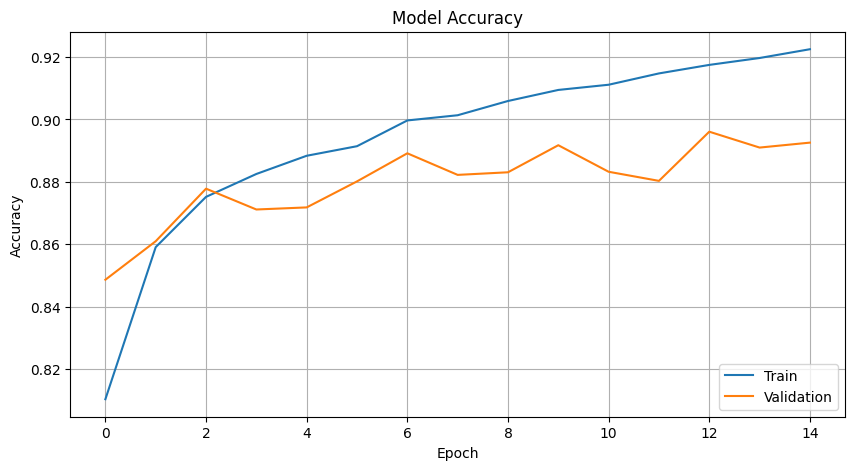

313/313 - 1s - 3ms/step - accuracy: 0.8847 - loss: 0.3621

Final Test Accuracy: 0.8847


In [ ]:
# Plotting training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)
plt.show()

# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')